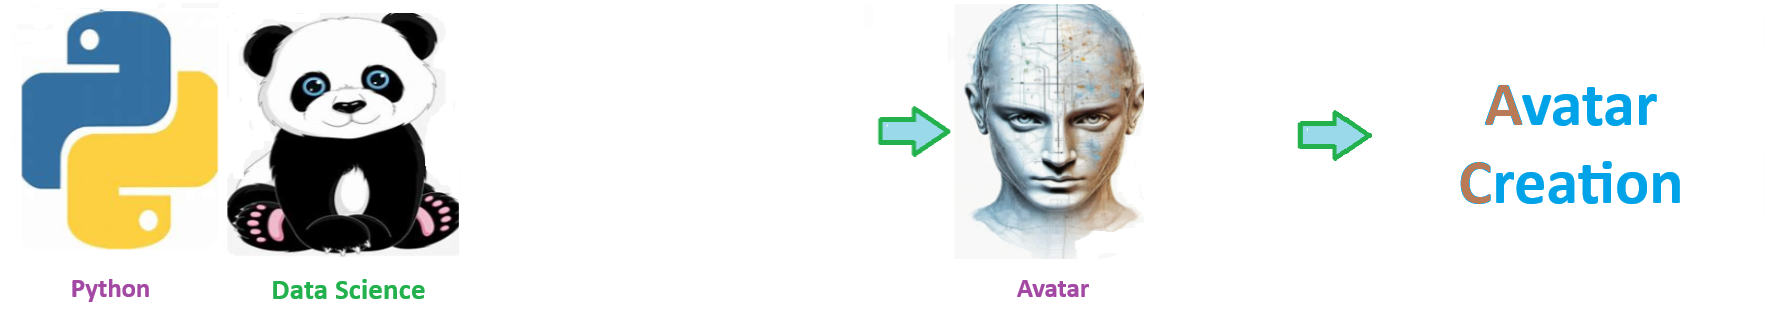

## 🧠 Avatar Creation 


# 🧩 Avatar Creation 

> Created by **ThriveAI  ...      Joe Eberle**  
> 🗓️ Started: April 18, 2025 
> 📫 Contact: [josepheberle@outlook.com](mailto:josepheberle@outlook.com)  
> 🔗 GitHub: [JoeEberle](https://github.com/JoeEberle/)


In [1]:
import os
import schedule
from datetime import datetime
import pandas as pd 
import quick_logger as ql
import talking_code as tc 
import file_manager as fm 
import story_board as sb 
import time
from IPython.display import Markdown, display, Image
print(f"Libraries Imported succesfully on {datetime.now().date()} at {datetime.now().time()}") 

Libraries Imported succesfully on 2026-03-05 at 21:42:54.294999


1. setup workspace

2. verify folders

3. copy/register avatar images

4. define avatar registry

5. test TTS separately

6. test stable video render separately

combine into create_short_video()

run sample calls

## Optional Step 0 - Intitiate Configuration Settings and name the overall solution

In [2]:
import configparser 
config = configparser.ConfigParser()
cfg = config.read('config.ini')  

solution_name = 'avatar_creation'

## Optional Step 0 - Intitiate Logging and debugging 

In [8]:
# Establish the Python Logger  
import logging # built in python library that does not need to be installed 
import quick_logger as ql

global start_stime 
start_time = ql.set_start_time()
logging = ql.create_logger_start(solution_name, start_time) 
ql.set_speaking_log(False)
ql.set_speaking_steps(False)
ql.pvlog('info',f'Process {solution_name} Step 0 - Initializing and starting Logging Process.') 

NameError: name 'solution_name' is not defined

In [5]:
import importlib
import sys
import platform

print("Python exe:", sys.executable)
print("Python version:", sys.version.split()[0])
print("Platform:", platform.platform())

print(f"\nLibraries:")

pkgs = [
    "numpy", "pandas",
    "pyttsx3",
    "PIL",          # pillow
    "moviepy",      # for video assembly (if you use it)
    "gtts",         # optional TTS alternative
]

for p in pkgs:
    try:
        importlib.import_module(p)
        print("✅", p)
    except Exception as e:
        print("❌", p, "->", type(e).__name__, e)

Python exe: C:\Users\josep\anaconda3\envs\py312_work\python.exe
Python version: 3.12.12
Platform: Windows-11-10.0.22631-SP0

Libraries:
✅ numpy
✅ pandas
✅ pyttsx3
✅ PIL
✅ moviepy
✅ gtts


In [9]:
from pathlib import Path
import os

# =========================================================
# Avatar Factory Workspace
# =========================================================
AVATAR_WORK_DIR = Path(r"D:\avatar_factory")

AVATAR_IMAGE_DIR = AVATAR_WORK_DIR / "avatars"
AVATAR_AUDIO_DIR = AVATAR_WORK_DIR / "audio"
AVATAR_VIDEO_DIR = AVATAR_WORK_DIR / "videos"
AVATAR_TEMP_DIR = AVATAR_WORK_DIR / "temp"
AVATAR_SCRIPT_DIR = AVATAR_WORK_DIR / "scripts"

# Create folders
for folder in [
    AVATAR_WORK_DIR,
    AVATAR_IMAGE_DIR,
    AVATAR_AUDIO_DIR,
    AVATAR_VIDEO_DIR,
    AVATAR_TEMP_DIR,
    AVATAR_SCRIPT_DIR,
]:
    folder.mkdir(parents=True, exist_ok=True)

# Point temp work to D drive
os.environ["TMPDIR"] = str(AVATAR_TEMP_DIR)
os.environ["TEMP"] = str(AVATAR_TEMP_DIR)
os.environ["TMP"] = str(AVATAR_TEMP_DIR)

print("Avatar workspace created:")
print("  WORK   :", AVATAR_WORK_DIR)
print("  IMAGES :", AVATAR_IMAGE_DIR)
print("  AUDIO  :", AVATAR_AUDIO_DIR)
print("  VIDEOS :", AVATAR_VIDEO_DIR)
print("  TEMP   :", AVATAR_TEMP_DIR)
print("  SCRIPTS:", AVATAR_SCRIPT_DIR)

Avatar workspace created:
  WORK   : D:\avatar_factory
  IMAGES : D:\avatar_factory\avatars
  AUDIO  : D:\avatar_factory\audio
  VIDEOS : D:\avatar_factory\videos
  TEMP   : D:\avatar_factory\temp
  SCRIPTS: D:\avatar_factory\scripts


In [6]:
from gtts import gTTS
from pathlib import Path

text = ("WellTell AI helps healthcare organizations find answers inside their own data. "
        "We connect clinical and operational data sources and use AI so that analysts, "
        "clinicians, and leaders can ask questions in plain language and get trusted insights quickly. "
        "It turns complicated healthcare data into something people can actually use to make decisions.")

mp3 = Path("avatar_voice_s1.mp3")
gTTS(text).save(str(mp3))
print("Audio file created:", mp3.resolve(), "bytes:", mp3.stat().st_size)

Audio file created: C:\Users\josep\avatar_creation\avatar_voice_s1.mp3 bytes: 200832


In [7]:
import pyttsx3
from pathlib import Path

text = ("WellTell AI helps healthcare organizations find answers inside their own data. "
        "We connect clinical and operational data sources and use AI so that analysts, "
        "clinicians, and leaders can ask questions in plain language and get trusted insights quickly. "
        "It turns complicated healthcare data into something people can actually use to make decisions.")

out = Path("avatar_voice_joe.wav")

engine = pyttsx3.init()
voices = engine.getProperty("voices")

# Microsoft David (male)
engine.setProperty("voice", voices[0].id)

engine.setProperty("rate", 160)

engine.save_to_file(text, str(out))
engine.runAndWait()

print("Audio file created:", out.resolve())


Audio file created: C:\Users\josep\avatar_creation\avatar_voice_joe.wav


In [7]:
from pathlib import Path

AVATAR_WORK_DIR = Path("D:/avatar_factory")

AVATAR_IMAGE_DIR = AVATAR_WORK_DIR / "avatars"
AVATAR_AUDIO_DIR = AVATAR_WORK_DIR / "audio"
AVATAR_VIDEO_DIR = AVATAR_WORK_DIR / "videos"
AVATAR_TEMP_DIR  = AVATAR_WORK_DIR / "temp"

# create directories if needed
for d in [AVATAR_IMAGE_DIR, AVATAR_AUDIO_DIR, AVATAR_VIDEO_DIR, AVATAR_TEMP_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("Avatar workspace:", AVATAR_WORK_DIR)

Avatar workspace: D:\avatar_factory


In [ ]:
from moviepy import ImageClip, AudioFileClip, vfx
from pathlib import Path

img_path = "avatar_base.png"          # your avatar image
audio_path = "avatar_voice_s1.mp3"    # your new audio
out_path = Path("avatar_s1.mp4")

W, H = 1920, 1080  # output size

audio = AudioFileClip(audio_path)
duration = audio.duration

# Base image clip
clip = ImageClip(img_path).with_duration(duration)

# 1) Resize image to cover the frame (like "background-size: cover")
# This prevents any black bars and avoids scrolling artifacts.
clip = clip.resized(height=H)  # make it at least as tall as the video

# If after resizing by height the width is still smaller than W, resize by width instead
if clip.w < W:
    clip = clip.resized(width=W)

# 2) Center-crop to exact 1080p
clip = clip.cropped(
    x_center=clip.w / 2,
    y_center=clip.h / 2,
    width=W,
    height=H
)

# 3) Optional: subtle zoom (comment out if you want perfectly static)
# clip = clip.with_effects([vfx.Resize(lambda t: 1.0 + 0.01*(t/duration))])

# 4) Attach audio
clip = clip.with_audio(audio)

clip.write_videofile(
    str(out_path),
    fps=30,
    codec="libx264",
    audio_codec="aac"
)

print("Saved:", out_path.resolve())

In [ ]:
from PIL import Image
from pathlib import Path

files = ["jessi.png", "courtney.png", "mariah.png"]

for f in files:
    p = Path(f)
    print(f, "exists:", p.exists(), "bytes:", p.stat().st_size if p.exists() else None)
    if p.exists():
        im = Image.open(p)
        print("  size:", im.size, "mode:", im.mode)

In [ ]:
from PIL import Image
from pathlib import Path

src_files = ["jessi.png", "joe.png", "courtney.png", "mariah.png"]
out_files = []

TARGET = 1024

def normalize_to_square(path_in: str, path_out: str, target: int = 1024):
    im = Image.open(path_in).convert("RGBA")
    w, h = im.size

    # center-crop to square
    side = min(w, h)
    left = (w - side) // 2
    top = (h - side) // 2
    im = im.crop((left, top, left + side, top + side))

    # resize to target
    im = im.resize((target, target), Image.LANCZOS)

    # (optional) tiny sharpen-like boost by re-saving; keep simple for now
    im.save(path_out)

for f in src_files:
    p = Path(f)
    out = p.with_name(p.stem + "_sq.png")
    normalize_to_square(str(p), str(out), TARGET)
    out_files.append(str(out))

print("Created:", out_files)

In [ ]:
from gtts import gTTS
from moviepy import ImageClip, AudioFileClip
from pathlib import Path

# 1) Put each face's script here
scripts = {
    "jessi": "Hi, I'm Jessi. WellTell AI helps healthcare teams get trusted answers from their own data, fast.",
    "joe": "Hi, I'm joe. WellTell AI helps healthcare organizations find answers inside their own data.",
    "courtney": "Hi, I'm Courtney. We connect clinical and operational sources so anyone can ask questions in plain language.",
    "mariah": "Hi, I'm Mariah. Our approach turns complicated healthcare data into clear insights leaders can act on."
    "joe_training": """Hi, I am training. We also offer AI training programs tailored specifically for healthcare personnel,
    including pathways such as AI+ Doctor, AI+ Nurse, AI+ Medical Assistant, AI+ Healthcare Administrator,
    AI+ Healthcare, and AI+ Pharma. Through these programs, clinicians, healthcare administrators, medical support staff,
    and pharmaceutical professionals gain a practical understanding of what artificial intelligence is, how it works,
    and how it can be applied in areas such as diagnostics, clinical decision support, patient monitoring, hospital operations,
    and healthcare analytics. Our training helps healthcare teams improve patient care, strengthen decision-making,
    and increase operational efficiency while maintaining ethical and regulatory compliance."""
}

faces = {
    "jessi": "jessi_sq.png",       # use _sq if you created them; otherwise use jessi.png
    "joe": "joe_sq.png",    
    "courtney": "courtney_sq.png",
    "mariah": "mariah_sq.png"
    "joe_training": "joe_sq.png",        
}

W, H = 1920, 1080

def make_audio(name: str, text: str) -> Path:
    mp3 = Path(f"voice_{name}.mp3")
    gTTS(text).save(str(mp3))
    return mp3

def make_video(name: str, face_png: str, mp3_path: Path) -> Path:
    out = Path(f"avatar_{name}.mp4")
    audio = AudioFileClip(str(mp3_path))
    duration = audio.duration

    clip = ImageClip(face_png).with_duration(duration)

    # cover + center-crop for stable 1080p
    clip = clip.resized(height=H)
    if clip.w < W:
        clip = clip.resized(width=W)
    clip = clip.cropped(x_center=clip.w/2, y_center=clip.h/2, width=W, height=H)

    clip = clip.with_audio(audio)

    clip.write_videofile(
        str(out),
        fps=30,
        codec="libx264",
        audio_codec="aac"
    )
    return out

outputs = []
for name, text in scripts.items():
    mp3 = make_audio(name, text)
    mp4 = make_video(name, faces[name], mp3)
    outputs.append(mp4)
    print(f"✅ Done: {mp4.name}")

print("All videos:", [p.name for p in outputs])

In [ ]:
from moviepy import VideoFileClip, concatenate_videoclips
from pathlib import Path

clips = [
    VideoFileClip("avatar_jessi.mp4"),
    VideoFileClip("avatar_joe.mp4"),    
    VideoFileClip("avatar_courtney.mp4"),
    VideoFileClip("avatar_mariah.mp4"),
]

final = concatenate_videoclips(clips, method="compose")
out = Path("avatar_all_4.mp4")

final.write_videofile(
    str(out),
    fps=30,
    codec="libx264",
    audio_codec="aac"
)

print("Saved:", out.resolve())

In [ ]:
import pyttsx3

engine = pyttsx3.init()
voices = engine.getProperty("voices")

for i, v in enumerate(voices):
    print(i, "NAME:", getattr(v, "name", ""))
    print("   ID:", v.id)
    print()

In [ ]:
import pyttsx3
from pathlib import Path

def tts_pyttsx3(text, out_wav, voice_index=0, rate=175):
    engine = pyttsx3.init()
    voices = engine.getProperty("voices")
    engine.setProperty("voice", voices[voice_index].id)
    engine.setProperty("rate", rate)
    engine.save_to_file(text, str(out_wav))
    engine.runAndWait()

tts_pyttsx3("Hi I'm Jessi.", Path("voice_jessi.wav"), voice_index=1, rate=185)
tts_pyttsx3("Hi I'm Courtney.", Path("voice_courtney.wav"), voice_index=1, rate=170)
tts_pyttsx3("Hi I'm Mariah.", Path("voice_mariah.wav"), voice_index=1, rate=160)
tts_pyttsx3("Hi I'm Joe.", Path("voice_joe.wav"), voice_index=0, rate=170)
print("WAVs created.")

In [ ]:
import pyttsx3

engine = pyttsx3.init()
voices = engine.getProperty("voices")

for i, v in enumerate(voices):
    print(i, v.name, "|", v.id)

In [ ]:
from pathlib import Path

FACE_PNG = "jessi.png"          # or "jessi_sq.png"
VOICE_MP3 = "voice_s1.mp3"      # your MP3

assert Path(FACE_PNG).exists(), f"Missing {FACE_PNG}"
assert Path(VOICE_MP3).exists(), f"Missing {VOICE_MP3}"

# Mouth box in RELATIVE coordinates (0..1) within the final 1920x1080 frame.
# These are starting guesses. We'll tweak after a quick render.
mouth = {
    "cx": 0.50,   # center x
    "cy": 0.66,   # center y
    "w":  0.18,   # mouth width
    "h_min": 0.015,  # closed height
    "h_max": 0.060,  # open height
}
print("Ready.")

In [ ]:
import os
print(f"current working directory {os.getcwd()} ") 

import os
print(os.listdir())

from pathlib import Path

FACE_PNG = "jessi.png"
VOICE_MP3 = "voice_jessi.mp3"

print("Face exists:", Path(FACE_PNG).exists())
print("Voice exists:", Path(VOICE_MP3).exists())

In [ ]:
from PIL import Image
from pathlib import Path

src_files = ["jessi.png", "courtney.png", "mariah.png", "joe.png"]
out_files = []

TARGET = 1024

def normalize_to_square(path_in: str, path_out: str, target: int = 1024):
    im = Image.open(path_in).convert("RGBA")
    w, h = im.size

    # center-crop to square
    side = min(w, h)
    left = (w - side) // 2
    top = (h - side) // 2
    im = im.crop((left, top, left + side, top + side))

    # resize to target
    im = im.resize((target, target), Image.LANCZOS)

    # (optional) tiny sharpen-like boost by re-saving; keep simple for now
    im.save(path_out)

for f in src_files:
    p = Path(f)
    out = p.with_name(p.stem + "_sq.png")
    normalize_to_square(str(p), str(out), TARGET)
    out_files.append(str(out))

print("Created:", out_files)
Created: ['jessi_sq.png', 'courtney_sq.png', 'mariah_sq.png']

In [ ]:
from gtts import gTTS

text = "WellTell AI helps healthcare organizations find answers inside their own data. We connect clinical and operational data sources and use AI so that analysts, clinicians, and leaders can ask questions in plain language and get trusted insights quickly. It turns complicated healthcare data into something people can actually use to make decisions."

tts = gTTS(text)
tts.save("avatar_voice_s2.mp3")

print("Audio file created: avatar_voice.mp3")

In [ ]:
from PIL import Image, ImageDraw, ImageFont
from pathlib import Path

W, H = 1024, 1024
img = Image.new("RGBA", (W, H), (245, 245, 245, 255))
d = ImageDraw.Draw(img)

# Head
d.ellipse((212, 140, 812, 740), fill=(255, 224, 189, 255), outline=(60, 60, 60, 255), width=6)

# Eyes
d.ellipse((390, 360, 450, 420), fill=(255,255,255,255), outline=(40,40,40,255), width=4)
d.ellipse((574, 360, 634, 420), fill=(255,255,255,255), outline=(40,40,40,255), width=4)
d.ellipse((412, 382, 432, 402), fill=(30,30,30,255))
d.ellipse((596, 382, 616, 402), fill=(30,30,30,255))

# Smile
d.arc((420, 460, 604, 610), start=15, end=165, fill=(120,40,40,255), width=8)

# Name plate
d.rounded_rectangle((180, 780, 844, 930), radius=40, fill=(30,30,30,255))
d.text((240, 820), "JOE", fill=(255,255,255,255))

out_img = Path("avatar_base.png")
img.save(out_img)
print("Saved:", out_img.resolve())

In [ ]:
from moviepy import ImageClip, AudioFileClip, vfx
import math
from pathlib import Path

img_path = "avatar_base.png"
audio_path = "avatar_voice.mp3"
out_path = Path("avatar_test.mp4")

audio = AudioFileClip(audio_path)
duration = audio.duration

clip = ImageClip(img_path).with_duration(duration)

# gentle zoom
clip = clip.with_effects([vfx.Resize(lambda t: 1.0 + 0.02*(t/duration))])

clip = clip.with_audio(audio)

clip.write_videofile(
    str(out_path),
    fps=30,
    codec="libx264",
    audio_codec="aac"
)

print("Saved:", out_path.resolve())

In [ ]:
import numpy as np
from pathlib import Path
from PIL import Image, ImageDraw
from moviepy import ImageClip, VideoClip, AudioFileClip

FACE_PNG = "jessi_sq.png"        # square version is best
VOICE_MP3 = "voice_jessi.mp3"
OUT_MP4  = "jessi_talking_mouth.mp4"

assert Path(FACE_PNG).exists(), f"Missing {FACE_PNG}"
assert Path(VOICE_MP3).exists(), f"Missing {VOICE_MP3}"

# Output video size
W, H = 1920, 1080
fps = 30

# ---- MOUTH POSITION (tweak these) ----
# cx, cy are relative positions in the final 1920x1080 frame (0..1)
mouth = {
    "cx": 0.52,
    "cy": 0.50,      # move up/down if needed (0.66 higher, 0.74 lower)
    "w":  0.14,      # mouth width
    "h_min": 0.010,  # closed height
    "h_max": 0.075,  # open height
}

# Load audio and build envelope
audio = AudioFileClip(VOICE_MP3)
duration = audio.duration

sr = 22050
hop = 1 / fps
y = audio.to_soundarray(fps=sr)
if y.ndim == 2:
    y = y.mean(axis=1)

win = int(sr * hop)
n = len(y) // win
rms = np.array([np.sqrt(np.mean(y[i*win:(i+1)*win]**2)) for i in range(n)])
rms = rms / (rms.max() + 1e-9)

# Smooth envelope
env = np.convolve(rms, np.ones(5)/5, mode="same")

# Make stable base frame (cover + crop)
base = ImageClip(FACE_PNG).with_duration(duration)
base = base.resized(height=H)
if base.w < W:
    base = base.resized(width=W)
base = base.cropped(x_center=base.w/2, y_center=base.h/2, width=W, height=H)
base_frame = base.get_frame(0)
if base_frame.shape[2] == 4:
    base_frame = base_frame[:, :, :3]

# Precompute mouth pixels
mx = int(mouth["cx"] * W)
my = int(mouth["cy"] * H)
mw = int(mouth["w"] * W)
hmin = int(mouth["h_min"] * H)
hmax = int(mouth["h_max"] * H)

def env_at(t):
    idx = int((t / duration) * (len(env) - 1))
    idx = max(0, min(len(env) - 1, idx))
    return float(env[idx])

def make_frame(t):
    openness = env_at(t)
    mh = int(hmin + openness * (hmax - hmin))

    img = Image.fromarray(base_frame.copy())
    d = ImageDraw.Draw(img)

    x0, y0 = mx - mw//2, my - mh//2
    x1, y1 = mx + mw//2, my + mh//2

    # mouth fill
    d.ellipse([x0, y0, x1, y1], fill=(35, 15, 15), outline=(10, 10, 10), width=2)

    # subtle "teeth" hint when open
    if mh > int(0.020 * H):
        d.line([(x0+10, my), (x1-10, my)], fill=(230, 230, 230), width=2)

    return np.array(img)

vid = VideoClip(make_frame, duration=duration).with_audio(audio)
vid.write_videofile(OUT_MP4, fps=fps, codec="libx264", audio_codec="aac")
print("Saved:", Path(OUT_MP4).resolve())

In [ ]:
from moviepy import ImageClip, AudioFileClip, vfx
from pathlib import Path
import math

FACE_PNG = "jessi_sq.png"
VOICE_MP3 = "voice_jessi.mp3"
OUT_MP4 = "jessi_clean_talking.mp4"

W, H = 1920, 1080
fps = 30

audio = AudioFileClip(VOICE_MP3)
duration = audio.duration

clip = ImageClip(FACE_PNG).with_duration(duration)

# Fill frame cleanly
clip = clip.resized(height=H)
if clip.w < W:
    clip = clip.resized(width=W)
clip = clip.cropped(x_center=clip.w/2, y_center=clip.h/2, width=W, height=H)

# subtle breathing zoom
clip = clip.with_effects([
    vfx.Resize(lambda t: 1.0 + 0.008 * math.sin(2 * math.pi * 0.25 * t))
])

clip = clip.with_audio(audio)

clip.write_videofile(
    OUT_MP4,
    fps=fps,
    codec="libx264",
    audio_codec="aac"
)

print("Saved:", Path(OUT_MP4).resolve())

In [1]:
from moviepy import ImageClip, AudioFileClip
from pathlib import Path

FACE_PNG = "jessi_sq.png"
VOICE_MP3 = "voice_jessi.mp3"
OUT_MP4 = "jessi_stable.mp4"

W, H = 1920, 1080
fps = 30

audio = AudioFileClip(VOICE_MP3)
duration = audio.duration

clip = ImageClip(FACE_PNG).with_duration(duration)

# Make image fill frame safely
clip = clip.resized(height=H)
if clip.w < W:
    clip = clip.resized(width=W)

# Center crop to exact 1920x1080
clip = clip.cropped(
    x_center=clip.w / 2,
    y_center=clip.h / 2,
    width=W,
    height=H
)

clip = clip.with_audio(audio)

clip.write_videofile(
    OUT_MP4,
    fps=fps,
    codec="libx264",
    audio_codec="aac"
)

print("Saved:", Path(OUT_MP4).resolve())

MoviePy - Building video jessi_stable.mp4.
MoviePy - Writing audio in jessi_stableTEMP_MPY_wvf_snd.mp4


MoviePy - Done.
MoviePy - Writing video jessi_stable.mp4



MoviePy - Done !
MoviePy - video ready jessi_stable.mp4
Saved: C:\Users\josep\avatar_creation\jessi_stable.mp4


In [ ]:
output_file = create_short_video(
    avatar_name="joe",
    text="Hello, I am Joe. Welcome to WellTell AI. We help healthcare organizations turn complex data into clear and trusted answers.",
    output_mp4="joe_intro.mp4",
    title="WellTell AI",
    aspect="landscape"
)

print("Created:", output_file)

In [2]:
from pathlib import Path
import os
import uuid
import math

from gtts import gTTS
import pyttsx3

from moviepy import (
    ImageClip,
    AudioFileClip,
    CompositeVideoClip,
)
from PIL import Image, ImageDraw, ImageFont


# =========================================================
# Avatar Registry
# =========================================================
AVATAR_REGISTRY = {
    "joe": {
        "image": "joe_sq.png",         # change if your Joe file has a different name
        "voice_engine": "pyttsx3",
        "voice_name": "david",         # maps to Microsoft David
        "rate": 160
    },
    "jessi": {
        "image": "jessi_sq.png",
        "voice_engine": "gtts",
        "voice_name": "default",
        "rate": 170
    },
    "courtney": {
        "image": "courtney_sq.png",
        "voice_engine": "gtts",
        "voice_name": "default",
        "rate": 165
    },
    "mariah": {
        "image": "mariah_sq.png",
        "voice_engine": "gtts",
        "voice_name": "default",
        "rate": 160
    },
}


# =========================================================
# Helpers
# =========================================================
def _get_dimensions(aspect: str) -> tuple[int, int]:
    aspect = aspect.lower().strip()
    if aspect == "landscape":
        return (1920, 1080)
    elif aspect == "portrait":
        return (1080, 1920)
    elif aspect == "square":
        return (1080, 1080)
    else:
        raise ValueError("aspect must be one of: 'landscape', 'portrait', 'square'")


def _resolve_voice_id(voice_name: str | None, voices) -> str:
    """
    Resolve a pyttsx3 voice by nickname.
    """
    if not voice_name:
        return voices[0].id

    voice_name = voice_name.lower()

    # Friendly aliases
    aliases = {
        "david": "david",
        "zira": "zira",
        "male": "david",
        "female": "zira",
    }

    target = aliases.get(voice_name, voice_name)

    for v in voices:
        if target in v.name.lower() or target in v.id.lower():
            return v.id

    # fallback to first available voice
    return voices[0].id


def _generate_audio_gtts(text: str, output_audio: Path, tld: str = "com") -> Path:
    """
    Generate MP3 using gTTS.
    """
    tts = gTTS(text=text, lang="en", tld=tld)
    tts.save(str(output_audio))
    return output_audio


def _generate_audio_pyttsx3(
    text: str,
    output_audio: Path,
    voice_name: str | None = None,
    rate: int = 160
) -> Path:
    """
    Generate WAV using pyttsx3.
    """
    engine = pyttsx3.init()
    voices = engine.getProperty("voices")
    voice_id = _resolve_voice_id(voice_name, voices)

    engine.setProperty("voice", voice_id)
    engine.setProperty("rate", rate)
    engine.save_to_file(text, str(output_audio))
    engine.runAndWait()
    return output_audio


def _make_title_banner(
    title_text: str,
    size: tuple[int, int],
    out_path: Path,
    banner_height_ratio: float = 0.12
) -> Path:
    """
    Create a transparent PNG title banner using Pillow.
    This avoids TextClip/font issues.
    """
    W, H = size
    banner_h = int(H * banner_height_ratio)

    img = Image.new("RGBA", (W, H), (0, 0, 0, 0))
    d = ImageDraw.Draw(img)

    # semi-transparent dark banner
    d.rectangle([(0, 0), (W, banner_h)], fill=(20, 20, 20, 180))

    # try a common font, fallback if unavailable
    try:
        font = ImageFont.truetype("arial.ttf", int(banner_h * 0.42))
    except Exception:
        font = ImageFont.load_default()

    bbox = d.textbbox((0, 0), title_text, font=font)
    text_w = bbox[2] - bbox[0]
    text_h = bbox[3] - bbox[1]

    x = (W - text_w) // 2
    y = (banner_h - text_h) // 2 - 2

    d.text((x, y), title_text, fill=(255, 255, 255, 255), font=font)

    img.save(out_path)
    return out_path


def _build_base_video_clip(
    image_path: str,
    duration: float,
    size: tuple[int, int]
):
    """
    Build a stable avatar clip with cover + center crop.
    """
    W, H = size

    clip = ImageClip(image_path).with_duration(duration)

    # cover by height first
    clip = clip.resized(height=H)
    if clip.w < W:
        clip = clip.resized(width=W)

    # center crop to exact output size
    clip = clip.cropped(
        x_center=clip.w / 2,
        y_center=clip.h / 2,
        width=W,
        height=H
    )

    return clip


# =========================================================
# Main Factory Function
# =========================================================
def create_short_video(
    avatar_name: str,
    text: str,
    output_mp4: str,
    audio_file: str | None = None,
    title: str | None = None,
    aspect: str = "landscape",
    voice_engine: str | None = None,
    voice_name: str | None = None,
    rate: int | None = None,
    overwrite: bool = True,
    audio_dir: str = ".",
    tld: str = "com"
) -> str:
    """
    Create a short talking-avatar MP4 from an avatar image + TTS audio.

    Parameters
    ----------
    avatar_name : str
        Key in AVATAR_REGISTRY, e.g. 'joe', 'jessi'
    text : str
        Text for text-to-speech. Ignored if audio_file is provided.
    output_mp4 : str
        Output MP4 path.
    audio_file : str | None
        Optional pre-generated audio path. If provided, TTS is skipped.
    title : str | None
        Optional title banner text.
    aspect : str
        'landscape', 'portrait', or 'square'
    voice_engine : str | None
        Override avatar default voice engine ('gtts' or 'pyttsx3')
    voice_name : str | None
        Override avatar default voice name
    rate : int | None
        Override avatar default speaking rate
    overwrite : bool
        Whether to overwrite output_mp4 if it exists
    audio_dir : str
        Directory for temporary/generated audio
    tld : str
        gTTS top-level domain, e.g. 'com', 'co.uk', 'com.au'

    Returns
    -------
    str
        Output MP4 path
    """
    avatar_name = avatar_name.lower().strip()

    if avatar_name not in AVATAR_REGISTRY:
        raise ValueError(f"Unknown avatar_name '{avatar_name}'. Available: {list(AVATAR_REGISTRY.keys())}")

    avatar = AVATAR_REGISTRY[avatar_name]
    image_path = avatar["image"]

    if not Path(image_path).exists():
        raise FileNotFoundError(f"Avatar image not found: {image_path}")

    output_path = Path(output_mp4)
    if output_path.exists() and not overwrite:
        raise FileExistsError(f"{output_mp4} already exists and overwrite=False")

    W, H = _get_dimensions(aspect)

    # Resolve voice settings
    final_voice_engine = voice_engine or avatar.get("voice_engine", "gtts")
    final_voice_name = voice_name or avatar.get("voice_name", "default")
    final_rate = rate if rate is not None else avatar.get("rate", 160)

    # Generate or use provided audio
    if audio_file:
        audio_path = Path(audio_file)
        if not audio_path.exists():
            raise FileNotFoundError(f"Provided audio_file not found: {audio_file}")
    else:
        if not text or not text.strip():
            raise ValueError("text must be provided when audio_file is not supplied")

        audio_dir_path = Path(audio_dir)
        audio_dir_path.mkdir(parents=True, exist_ok=True)

        unique_id = uuid.uuid4().hex[:8]

        if final_voice_engine == "gtts":
            audio_path = audio_dir_path / f"{avatar_name}_{unique_id}.mp3"
            _generate_audio_gtts(text=text, output_audio=audio_path, tld=tld)

        elif final_voice_engine == "pyttsx3":
            audio_path = audio_dir_path / f"{avatar_name}_{unique_id}.wav"
            _generate_audio_pyttsx3(
                text=text,
                output_audio=audio_path,
                voice_name=final_voice_name,
                rate=final_rate
            )
        else:
            raise ValueError("voice_engine must be 'gtts' or 'pyttsx3'")

    # Load audio
    audio = AudioFileClip(str(audio_path))
    duration = audio.duration

    # Build base clip
    base_clip = _build_base_video_clip(
        image_path=image_path,
        duration=duration,
        size=(W, H)
    ).with_audio(audio)

    final_clip = base_clip

    # Optional title banner
    temp_banner_path = None
    if title:
        temp_banner_path = Path(f"_temp_title_{uuid.uuid4().hex[:8]}.png")
        _make_title_banner(
            title_text=title,
            size=(W, H),
            out_path=temp_banner_path
        )

        title_clip = ImageClip(str(temp_banner_path)).with_duration(duration)
        final_clip = CompositeVideoClip([base_clip, title_clip], size=(W, H))

    # Render MP4
    final_clip.write_videofile(
        str(output_path),
        fps=30,
        codec="libx264",
        audio_codec="aac"
    )

    # Cleanup
    try:
        audio.close()
    except Exception:
        pass

    try:
        base_clip.close()
    except Exception:
        pass

    try:
        final_clip.close()
    except Exception:
        pass

    if temp_banner_path and temp_banner_path.exists():
        try:
            temp_banner_path.unlink()
        except Exception:
            pass

    return str(output_path)

In [4]:
training_text = """Hi, I am training. We also offer AI training programs tailored specifically for healthcare personnel,
    including pathways such as AI+ Doctor, AI+ Nurse, AI+ Medical Assistant, AI+ Healthcare Administrator,
    AI+ Healthcare, and AI+ Pharma. Through these programs, clinicians, healthcare administrators, medical support staff,
    and pharmaceutical professionals gain a practical understanding of what artificial intelligence is, how it works,
    and how it can be applied in areas such as diagnostics, clinical decision support, patient monitoring, hospital operations,
    and healthcare analytics. Our training helps healthcare teams improve patient care, strengthen decision-making,
    and increase operational efficiency while maintaining ethical and regulatory compliance."""

In [5]:
training_text = """"Hello, I am Jessi.  We also offer AI training programs tailored specifically for healthcare personnel,
    including pathways such as AI+ Doctor, AI+ Nurse, AI+ Medical Assistant, AI+ Healthcare Administrator,
    AI+ Healthcare, and AI+ Pharma. Through these programs, clinicians, healthcare administrators, medical support staff,
    and pharmaceutical professionals gain a practical understanding of what artificial intelligence is, how it works,
    and how it can be applied in areas such as diagnostics, clinical decision support, patient monitoring, hospital operations,
    and healthcare analytics. Our training helps healthcare teams improve patient care, strengthen decision-making,
    and increase operational efficiency while maintaining ethical and regulatory compliance."""

output_file = create_short_video(
    avatar_name="Jessi",
    text=training_text ,
    output_mp4="jessi_training.mp4",
    title="Training",
    aspect="landscape"
)

print("Created:", output_file)

MoviePy - Building video jessi_training.mp4.
MoviePy - Writing audio in jessi_trainingTEMP_MPY_wvf_snd.mp4


MoviePy - Done.
MoviePy - Writing video jessi_training.mp4



MoviePy - Done !
MoviePy - video ready jessi_training.mp4
Created: jessi_training.mp4


In [6]:
output_file = create_short_video(
    avatar_name="jessi",
    text="Hi I am Jessi. WellTell AI helps healthcare organizations find answers inside their own data. We connect clinical and operational data sources and use AI to produce trusted insights quickly.",
    output_mp4="jessi_intro.mp4",
    title="Hospitals ROI",
    aspect="landscape"
)

print("Created:", output_file)

MoviePy - Building video jessi_intro.mp4.
MoviePy - Writing audio in jessi_introTEMP_MPY_wvf_snd.mp4


MoviePy - Done.
MoviePy - Writing video jessi_intro.mp4



MoviePy - Done !
MoviePy - video ready jessi_intro.mp4
Created: jessi_intro.mp4


In [3]:
output_file = create_short_video(
    avatar_name="joe",
    text="Hello, I am Joe. Welcome to WellTell AI. We help healthcare organizations turn complex data into clear and trusted answers.",
    output_mp4="joe_intro.mp4",
    title="WellTell AI",
    aspect="landscape"
)

print("Created:", output_file)

MoviePy - Building video joe_intro.mp4.
MoviePy - Writing audio in joe_introTEMP_MPY_wvf_snd.mp4


MoviePy - Done.
MoviePy - Writing video joe_intro.mp4



MoviePy - Done !
MoviePy - video ready joe_intro.mp4
Created: joe_intro.mp4


## Step 0 - Process End - display log

In [ ]:
# Calculate and classify the process performance 
status = ql.calculate_process_performance(solution_name, start_time) 
print(ql.append_log_file(solution_name))  

#### https://github.com/JoeEberle/ -- josepheberle@outlook.com